In [ ]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from osrs_anomaly_ml.util import features
from osrs_anomaly_ml.util.common import fill_missing_values_df, flatten_json_to_df, normalize_number, fill_missing_hiscore_data, prefix_columns, flatten_hiscore_record, read_data_dump
from osrs_anomaly_ml.util.log import get_logger
from dotenv import load_dotenv
load_dotenv(override=True)

logger = get_logger(__name__)

# make a .env file in project root or use BACKUP_IN_FILE
BACKUP_IN_FILE=''
in_file = os.getenv("NOTEBOOK_IN_FILE", BACKUP_IN_FILE)

logger.debug('reading json')
data_json = read_data_dump(in_file)
logger.debug('json loaded')


# rename rank to total rank to remove confusion with category rank
# flatten 'record' json 'property'
logger.debug('preprocess json')
data = flatten_hiscore_record(data_json)

logger.debug('flatten json into df')
df = flatten_json_to_df(data, sep="_")

logger.debug("before prefix features: " + ", ".join(sorted(df.columns)))

logger.debug('prefix columns')
df = prefix_columns(df)

logger.debug("after prefix features: " + ", ".join(sorted(df.columns)))


logger.debug('fill missing values df')
df = fill_missing_values_df(df)
# todo: add missing skills, misc and bosses
# dataset is large enough atm that there are no missing values
df = fill_missing_hiscore_data(df)

logger.debug('normalize numeric')
df = df.map(normalize_number)

# can maybe keep combat lvl float
float_cols = df.select_dtypes(include="float64").columns
float_cols = float_cols.drop("is_bot", errors="ignore")
df[float_cols] = df[float_cols].astype("int64")

df_metadata = df[["is_bot", "username"]].copy() 
df = df.set_index("username")

df

2026-04-18 23:13:20,720 - DEBUG    - reading json (3960599771.py:16)
2026-04-18 23:13:24,310 - DEBUG    - json loaded (3960599771.py:18)
2026-04-18 23:13:24,310 - DEBUG    - preprocess json (3960599771.py:23)
2026-04-18 23:13:24,750 - DEBUG    - flatten json into df (3960599771.py:26)
2026-04-18 23:13:39,733 - DEBUG    - before prefix features: category_rank, combat_lvl_value, is_bot, misc_amoxliatl_kc, misc_amoxliatl_rank, misc_araxxor_kc, misc_araxxor_rank, misc_armadyl_kc, misc_armadyl_rank, misc_artio_kc, misc_artio_rank, misc_bandos_kc, misc_bandos_rank, misc_barrows_chests_kc, misc_barrows_chests_rank, misc_bh_hunter_kc, misc_bh_hunter_rank, misc_bh_legacy_hunter_kc, misc_bh_legacy_hunter_rank, misc_bh_legacy_rogue_kc, misc_bh_legacy_rogue_rank, misc_bh_rogue_kc, misc_bh_rogue_rank, misc_brutus_kc, misc_brutus_rank, misc_bryophyta_kc, misc_bryophyta_rank, misc_callisto_kc, misc_callisto_rank, misc_calvarion_kc, misc_calvarion_rank, misc_cerberus_kc, misc_cerberus_rank, misc_cg_kc

In [ ]:
logger.debug('Start FE')
logger.debug('FE: add ratios')
df = features.add_username_ratio(df) # WOP
df = features.add_combat_ratio_lvl(df)
df = features.add_combat_ratio_xp(df) 
df = features.add_skill_ratios(df)
df = features.add_boss_ratios(df)

logger.debug('FE: add patterns')
df = features.add_scurrius_corp_pattern(df)

logger.debug('FE: log transform')
df = features.transform_skill_xp_to_log(df)

logger.debug('FE: Apply weights')
weights = {
    # "combat_ratio_lvl_missing_flag": 1,
}
df = features.apply_feature_weights(df, weights)

logger.debug('FE: Add soft features')
df = features.add_soft_features(
    df,
    # cols=["combat_ratio_xp_missing_flag"],
    cols=["total_lvl"],
    prefix="log_",
    method="log1p"
)

logger.debug('FE: remove columns')
df = features.remove_total_category_ranks(df)
# skills
df = features.remove_lvl(df, "skill_")
df = features.remove_xp(df, "skill_")
df = features.remove_rank(df, "skill_")

df = features.remove_lvl(df, "log_skill_")
df = features.remove_xp(df, "log_skill_")
df = features.remove_rank(df, "log_skill_")

df = features.remove_xp(df, "total_")
df = features.remove_xp(df, "log_total")
df = features.remove_xp(df, "log_combat")

# misc
df = features.remove_rank(df, "misc_")
df = features.remove_kc(df, "misc_")

# boss
df = features.remove_rank(df, "boss_")
df = features.remove_rank(df, "log_boss")
df = features.remove_kc(df, "boss_")
df = features.remove_kc(df, "log_boss")

df = df.sort_index(axis=1)

# df = features.remove(df, [
#     "combat_lvl_value", 
#     "combat_ratio_lvl_missing_flag", 
#     "combat_ratio_xp_missing_flag", 
#     "total_boss_kc",
#     "top1_boss_kc",
#     "top2_boss_kc_sum",
#     "total_lvl",
#     "xp_per_lvl",
#     "non_combat_xp",
#     "construction_vs_other_noncombat_xp_ratio",
#     ])

df = features.remove(df, [
    "nonzero_bosses",
    "total_lvl",
])



df = features.remove(df, ["is_bot"])

df

2026-04-18 23:13:49,220 - DEBUG    - Start FE (2484081352.py:3)
2026-04-18 23:13:49,221 - DEBUG    - FE: add ratios (2484081352.py:4)
d:\School\bap\2526-bachelorsthesis\bachproef-ml\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
2026-04-18 23:14:05,160 - DEBUG    - FE: add patterns (2484081352.py:11)
2026-04-18 23:14:05,162 - DEBUG    - FE: log transform (2484081352.py:14)
2026-04-18 23:14:05,290 - DEBUG    - FE: Apply weights (2484081352.py:17)
2026-04-18 23:14:05,291 - DEBUG    - FE: Add soft features (2484081352.py:23)
2026-04-18 23:14:05,332 - INFO     - Created soft features: ['log_total_lvl'] (features.py:268)
2026-04-18 23:14:05,340 - DEBUG    - FE: remove columns (2484081352.py:32)


,boss_sparsity,combat_ratio_lvl,combat_ratio_lvl_missing_flag,combat_ratio_xp,combat_ratio_xp_missing_flag,construction_vs_other_noncombat_xp_ratio,high_skill_xp_ratio,kc_entropy,log_total_lvl,low_skill_xp_ratio,...,skill_diversity_count,sub2_bosses_flag,timestamp,top1_boss_kc,top1_boss_ratio,top2_boss_kc_sum,top2_boss_ratio,total_boss_kc,xp_entropy,xp_per_lvl
username,,,,,,,,,,,,,,,,,,,,,
parrotman50,0.304348,0.358881,0,0.923180,0,0.433789,0.458333,1.763769e-02,7.566311,0.000000,...,23,0,2026-03-13T20:04:33.387446+00:00,100000,0.997994,100100,0.998992,100201,1.883936,2.924273e+05
Purpsauce,0.710145,0.291667,0,0.781036,0,0.049918,0.960000,1.006668e+00,7.773594,0.000000,...,24,0,2026-03-13T20:04:32.546779+00:00,70000,0.809829,73651,0.852067,86438,2.524948,5.358467e+05
Dwyne,0.811594,0.319797,0,0.873376,0,0.184259,0.800000,1.350934e+00,7.681560,0.000000,...,24,0,2026-03-13T20:04:33.344742+00:00,47195,0.739444,49467,0.775041,63825,2.172659,3.464961e+05
Bounce It,0.652174,0.309790,0,0.585422,0,0.099985,0.920000,1.289026e+00,7.713338,0.000000,...,24,0,2026-03-13T20:04:32.380160+00:00,39819,0.702858,46844,0.826858,56653,2.540682,2.985215e+05
Flikker,0.913043,0.297425,0,0.365660,0,0.009765,0.920000,3.030183e+00,7.754053,0.000000,...,24,0,2026-03-13T20:04:33.776127+00:00,36413,0.268050,46490,0.342231,135844,2.938490,1.093239e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NAFASMANUAL,0.014493,0.678161,0,0.868560,0,53.585170,0.250000,-1.000000e-09,6.664409,0.550000,...,19,1,2026-03-19T12:51:26.132305+00:00,76,1.000000,76,1.000000,76,1.732306,2.931185e+04
intan90,0.028986,0.474627,0,0.954533,0,0.007846,0.250000,5.719017e-01,7.201171,0.250000,...,23,1,2026-03-19T12:52:05.582853+00:00,2207,0.741101,2978,1.000000,2978,1.941370,4.294604e+04
TAKIYA JOKO,0.014493,0.680851,0,0.897049,0,53.340683,0.238095,-1.000000e-09,6.684612,0.571429,...,20,1,2026-03-19T12:52:53.651840+00:00,833,1.000000,833,1.000000,833,1.666327,3.670122e+04


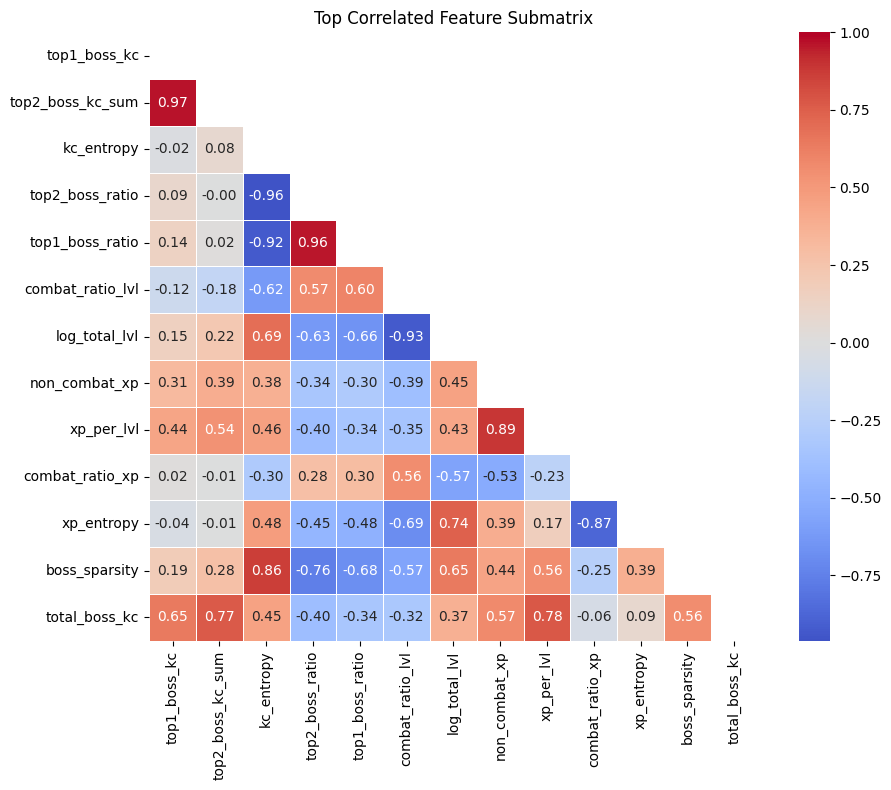

In [16]:
corr = df.drop(columns=['timestamp']).corr()

# mask self-correlations + duplicate pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# stack and get absolute correlations
corr_pairs = upper.abs().stack()

# top 10 pairs + features from top pairs
top10 = corr_pairs.sort_values(ascending=False).head(10)
top_features = list(dict.fromkeys([i for pair in top10.index for i in pair]))

subset_corr = corr.loc[top_features, top_features]
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    subset_corr, 
    mask=mask, 
    cmap="coolwarm", 
    vmax=1, 
    center=0,
    square=True, 
    linewidths=0.5, 
    annot=True, 
    fmt=".2f"
)
plt.title("Top Correlated Feature Submatrix")
plt.tight_layout()
display(plt.gcf())
plt.close()

In [17]:
df

,boss_sparsity,combat_lvl_value,combat_ratio_lvl,combat_ratio_lvl_missing_flag,combat_ratio_xp,combat_ratio_xp_missing_flag,construction_vs_other_noncombat_xp_ratio,high_skill_xp_ratio,kc_entropy,log_total_level,...,sub2_bosses_flag,timestamp,top1_boss_kc,top1_boss_ratio,top2_boss_kc_sum,top2_boss_ratio,total_boss_kc,total_level,xp_entropy,xp_per_lvl
username,,,,,,,,,,,,,,,,,,,,,
parrotman50,0.304348,126,0.358881,0,0.923180,0,0.433789,0.458333,1.763769e-02,7.566311,...,0,2026-03-13T20:04:33.387446+00:00,100000,0.997994,100100,0.998992,100201,1931,1.883936,2.924273e+05
Purpsauce,0.710145,126,0.291667,0,0.781036,0,0.049918,0.960000,1.006668e+00,7.773594,...,0,2026-03-13T20:04:32.546779+00:00,70000,0.809829,73651,0.852067,86438,2376,2.524948,5.358467e+05
Dwyne,0.811594,126,0.319797,0,0.873376,0,0.184259,0.800000,1.350934e+00,7.681560,...,0,2026-03-13T20:04:33.344742+00:00,47195,0.739444,49467,0.775041,63825,2167,2.172659,3.464961e+05
Bounce It,0.652174,126,0.309790,0,0.585422,0,0.099985,0.920000,1.289026e+00,7.713338,...,0,2026-03-13T20:04:32.380160+00:00,39819,0.702858,46844,0.826858,56653,2237,2.540682,2.985215e+05
Flikker,0.913043,126,0.297425,0,0.365660,0,0.009765,0.920000,3.030183e+00,7.754053,...,0,2026-03-13T20:04:33.776127+00:00,36413,0.268050,46490,0.342231,135844,2330,2.938490,1.093239e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NAFASMANUAL,0.014493,109,0.678161,0,0.868560,0,53.585170,0.250000,-1.000000e-09,6.664409,...,1,2026-03-19T12:51:26.132305+00:00,76,1.000000,76,1.000000,76,783,1.732306,2.931185e+04
intan90,0.028986,121,0.474627,0,0.954533,0,0.007846,0.250000,5.719017e-01,7.201171,...,1,2026-03-19T12:52:05.582853+00:00,2207,0.741101,2978,1.000000,2978,1340,1.941370,4.294604e+04
TAKIYA JOKO,0.014493,112,0.680851,0,0.897049,0,53.340683,0.238095,-1.000000e-09,6.684612,...,1,2026-03-19T12:52:53.651840+00:00,833,1.000000,833,1.000000,833,799,1.666327,3.670122e+04
